# Credit Card Fraud Detection Analysis





In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/shali/OneDrive/Desktop/creditcard.csv")
df.head()
df.shape

(284807, 31)

In [42]:
df.isnull().sum().sum()

np.int64(0)

In [43]:
df.duplicated().sum()

np.int64(1081)

In [44]:
df = df.drop_duplicates()
df.shape

(283726, 31)

In [45]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [46]:
fraud_rate = df["Class"].mean() * 100
print(f"Fraud makes up {fraud_rate:.2f}% of all transactions")

Fraud makes up 0.17% of all transactions


In [47]:
df.groupby("Class")["Amount"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
Class,,,,,
0,283253,88.413575,22.00,0.0,25691.16
1,473,123.871860,9.82,0.0,2125.87


**Observation:** Fraud is extremely rare, but average fraud amounts are actually *higher* than legit ones, while the *median* fraud amount is much lower. This means most frauds are small "test" transactions, with a few large ones pulling the average up.

##  When does fraud happen? (Time pattern)

The `Time` column is seconds since the first transaction. Convert it to an hour of the day (0-23) so it's readable.

In [48]:
df["Hour"] = (df["Time"] // 3600) % 24
df.groupby("Hour")["Class"].mean().sort_values(ascending=False).head(6)

Hour
2.0     0.014510
4.0     0.010436
3.0     0.004875
5.0     0.003681
7.0     0.003180
11.0    0.003158
Name: Class, dtype: float64

**Observation:** Fraud follows a clear repeating pattern — it spikes hard during one specific 3-hour window every 24-hour cycle. This is commonly believed to be early morning (around 2-4 AM) for this dataset, though we can't 100% confirm the exact clock time from the data alone.


##  Which columns actually separate fraud from legit transactions?

The columns V1-V28 are anonymized transaction details. Compare their average value for fraud vs. legit, and rank by the size of the gap — the bigger the gap, the more useful the column is as a fraud signal.

In [ ]:
v_cols = [c for c in df.columns if c.startswith("V")]
mean_by_class = df.groupby("Class")[v_cols].mean()
signal_strength = (mean_by_class.loc[1] - mean_by_class.loc[0]).abs().sort_values(ascending=False)
signal_strength.head(6)

V14    6.847614
V3     6.742452
V17    6.474249
V12    6.112730
V10    5.460937
V7     5.186359
dtype: float64

**Top signals:** V14, V3, V17, V12, V10, V7. We'll focus on the top 3 — V14, V3, V17 — to keep the analysis simple and easy to explain.

##  Finding the exact "danger zone" for each top feature

Split each feature into 10 equal-sized buckets and check the fraud rate in each bucket. This shows exactly which value range is riskiest — no complicated math, just grouping and counting.

In [56]:
# --- V14 ---
df["V14_bin"] = pd.qcut(df["V14"], 10, duplicates="drop")
print("--- V14 ---")
print(df.groupby("V14_bin", observed=True)["Class"].agg(["count", "sum", "mean"]))

--- V14 ---
                   count  sum      mean
V14_bin                                
(-19.215, -1.003]  28373  426  0.015014
(-1.003, -0.567]   28373   12  0.000423
(-0.567, -0.313]   28372    7  0.000247
(-0.313, -0.12]    28373    3  0.000106
(-0.12, 0.0502]    28372    3  0.000106
(0.0502, 0.216]    28373    3  0.000106
(0.216, 0.393]     28372    4  0.000141
(0.393, 0.608]     28373    2  0.000070
(0.608, 0.979]     28372    3  0.000106
(0.979, 10.527]    28373   10  0.000352


In [57]:
# --- V3 ---
df["V3_bin"] = pd.qcut(df["V3"], 10, duplicates="drop")
print("--- V3 ---")
print(df.groupby("V3_bin", observed=True)["Class"].agg(["count", "sum", "mean"]))

--- V3 ---
                   count  sum      mean
V3_bin                                 
(-48.327, -1.801]  28375  370  0.013040
(-1.801, -1.168]   28372   28  0.000987
(-1.168, -0.616]   28371   20  0.000705
(-0.616, -0.199]   28373   17  0.000599
(-0.199, 0.18]     28372    9  0.000317
(0.18, 0.497]      28373    6  0.000211
(0.497, 0.844]     28372    8  0.000282
(0.844, 1.215]     28373    9  0.000317
(1.215, 1.676]     28372    2  0.000070
(1.676, 9.383]     28373    4  0.000141


In [58]:
# --- V17 ---
df["V17_bin"] = pd.qcut(df["V17"], 10, duplicates="drop")
print("--- V17 ---")
print(df.groupby("V17_bin", observed=True)["Class"].agg(["count", "sum", "mean"]))

--- V17 ---
                   count  sum      mean
V17_bin                                
(-25.164, -0.804]  28373  359  0.012653
(-0.804, -0.576]   28373    1  0.000035
(-0.576, -0.397]   28372    3  0.000106
(-0.397, -0.236]   28373    2  0.000070
(-0.236, -0.0659]  28372    7  0.000247
(-0.0659, 0.105]   28373    6  0.000211
(0.105, 0.296]     28372    8  0.000282
(0.296, 0.518]     28373    7  0.000247
(0.518, 0.907]     28372   21  0.000740
(0.907, 9.254]     28373   59  0.002079


**Observation:** For all three features, the **lowest bucket** (most negative values) has a fraud rate 10-100x higher than every other bucket:
- V14 < about -1 → high risk
- V3 < about -1.8 → high risk
- V17 < about -0.8 → high risk

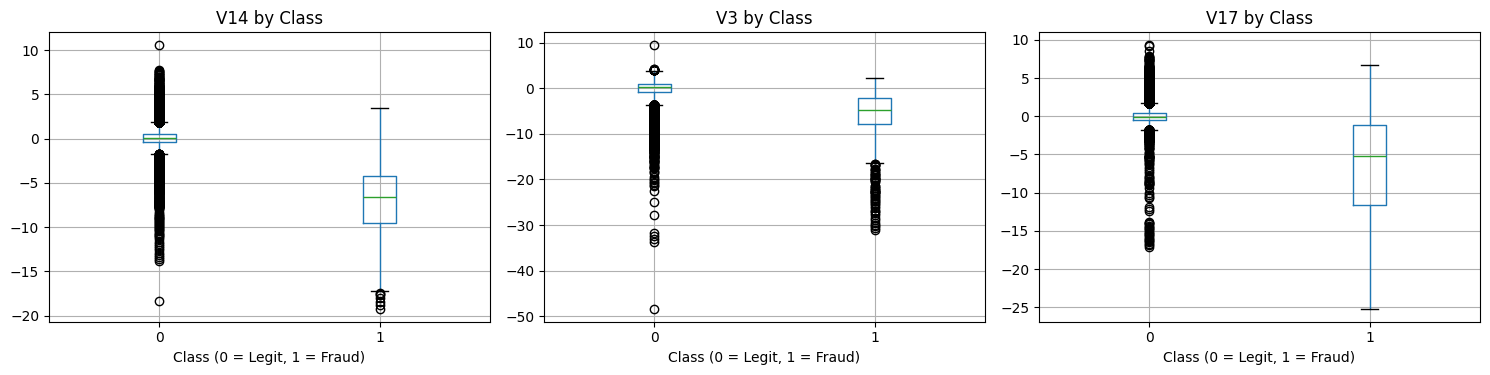

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["V14", "V3", "V17"]):
    df.boxplot(column=col, by="Class", ax=ax)
    ax.set_title(f"{col} by Class")
    ax.set_xlabel("Class (0 = Legit, 1 = Fraud)")
plt.suptitle("")
plt.tight_layout()
plt.show()

##  Do the top features overlap?

Checking correlation so we don't build redundant rules using columns that say the same thing.

In [52]:
df[["V14", "V3", "V17"]].corr()

,V14,V3,V17
V14,1.000000,-0.003027,-0.013551
V3,-0.003027,1.000000,-0.008159
V17,-0.013551,-0.008159,1.000000


**Observation:** The correlation between these three is low, so each one adds genuinely new information — good, they're worth combining into a rule.

##  Building a simple rule-based fraud trigger 

Two versions, so the fraud team can choose based on their tolerance for false alarms:

- **Wide net (OR rule):** flag if ANY of the 3 features looks risky → catches more fraud, but more false alarms.
- **Tight net (AND rule):** flag only if ALL 3 features look risky → catches less fraud, but far fewer false alarms.

In [65]:
df["flag_wide"] = (
    (df["V14"] < -1) |
    (df["V3"] < -1.8) |
    (df["V17"] < -0.8)
)

df["flag_tight"] = (
    (df["V14"] < -1) &
    (df["V3"] < -1.8) &
    (df["V17"] < -0.8)
)

In [70]:
# ---------- WIDE RULE ----------
print("WIDE NET (OR rule):")

total_fraud = df["Class"].sum()
print("Total real frauds in the data:", total_fraud)

flagged_rows = df[df["flag_wide"] == True]
print("Total transactions flagged:", len(flagged_rows))

caught = flagged_rows[flagged_rows["Class"] == 1]
print("Of those, actually fraud (correctly caught):", len(caught))

false_alarms = flagged_rows[flagged_rows["Class"] == 0]
print("Of those, actually innocent (false alarms):", len(false_alarms))

catch_rate = len(caught) / total_fraud * 100
print("Catch rate:", round(catch_rate, 1), "%")

precision = len(caught) / len(flagged_rows) * 100          
print("Precision (of flagged, % actually fraud):", round(precision, 2), "%") 

WIDE NET (OR rule):
Total real frauds in the data: 473
Total transactions flagged: 76548
Of those, actually fraud (correctly caught): 439
Of those, actually innocent (false alarms): 76109
Catch rate: 92.8 %
Precision (of flagged, % actually fraud): 0.57 %


In [71]:
# ---------- TIGHT RULE ----------
print("TIGHT NET (AND rule):")

total_fraud = df["Class"].sum()
print("Total real frauds in the data:", total_fraud)

flagged_rows = df[df["flag_tight"] == True]
print("Total transactions flagged:", len(flagged_rows))

caught = flagged_rows[flagged_rows["Class"] == 1]
print("Of those, actually fraud (correctly caught):", len(caught))

false_alarms = flagged_rows[flagged_rows["Class"] == 0]
print("Of those, actually innocent (false alarms):", len(false_alarms))

catch_rate = len(caught) / total_fraud * 100
print("Catch rate:", round(catch_rate, 1), "%")

precision = len(caught) / len(flagged_rows) * 100
print("Precision (of flagged, % actually fraud):", round(precision, 2), "%")

TIGHT NET (AND rule):
Total real frauds in the data: 473
Total transactions flagged: 730
Of those, actually fraud (correctly caught): 316
Of those, actually innocent (false alarms): 414
Catch rate: 66.8 %
Precision (of flagged, % actually fraud): 43.29 %


##  Combining time-of-day with amount

Check if the risky early-morning hours also tend to involve small "test" amounts.

In [55]:
df.groupby("Hour")["Amount"].agg(["mean", "median", "count"]).round(2).head(6)

,mean,median,count
Hour,,,
0.0,60.59,12.28,7647
1.0,62.77,18.98,4208
2.0,70.41,17.26,3308
3.0,51.76,15.95,3487
4.0,77.16,15.95,2204
5.0,50.70,11.85,2988


In [72]:
df.to_csv("fraud_analysis_powerbi.csv", index=False)

##  Conclusion 

**Which patterns signal fraud?**
- Three anonymized features — **V14, V3, and V17** — show a clear, low-overlap signal: when all three drop into their most negative ranges, a transaction is far more likely to be fraudulent.
- Fraud shows a strong, recurring spike in a specific 2-3 hour window within each 24-hour cycle. Based on how this dataset is typically documented (transactions starting near midnight), this window is commonly interpreted as early morning (around 2-4 AM) — though the exact clock alignment isn't independently verifiable from the data alone.
- Fraud amounts have a low median but a higher average, meaning most fraud attempts start small.

**Recommended real-time alert triggers:**
1. **Primary trigger (tight net):** Flag a transaction when V14 < -1 AND V3 < -1.8 AND V17 < -0.8. In testing, this caught 66.8% of real fraud (316 of 473) while wrongly flagging only 414 innocent transactions — precise enough for automatic hold/block.
2. **Secondary trigger (wide net):** Flag a transaction when ANY of the three conditions is true. This caught 92.8% of fraud (439 of 473), but flagged 76,109 innocent transactions too — too noisy for auto-blocking, but useful as a "worth reviewing" queue for a human analyst.
3. **Risk booster:** Treat transactions occurring during the identified high-risk time window as higher priority for review, especially when combined with a small transaction amount.

